# Module 3: Machine Learning
In Module 1, we showed some of the easiest ways to understand AI with regression and classification lines.  Module 2, we transition from trying to draw a bunch of lines into Neural Networks. In this module, I wanted to introduce you to concept of Machine Learning. This particular expression of AI is trying to learn from data without being explicitly with every class or every rule. 

In this setup; let us assume we are using the Predictor that uses the Neural Network from Module 2.
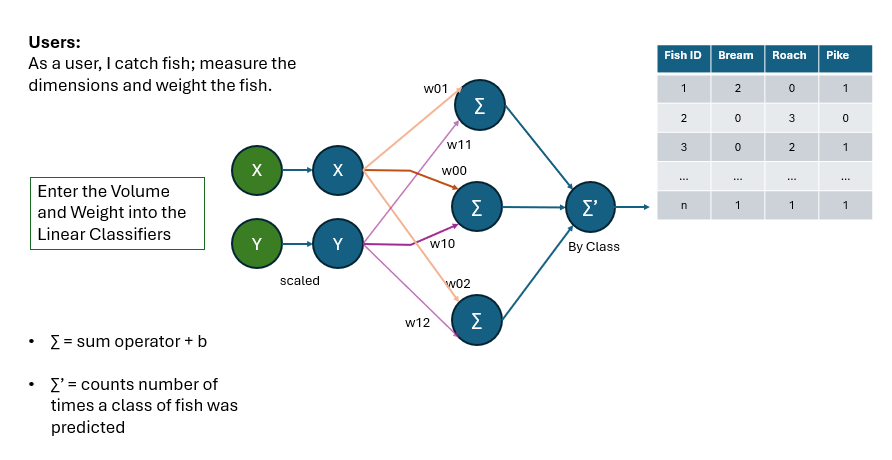

As we feed the Neural Network from Module 2 real data, we know that the Predictor might say a fish could be from 2 to even 3 species. We did not force Module 2 to have a single output, aka a Classifier like we tried in Module 1.

Module 3 is our chance to practice Machine Learning. The real-world rule is: "We will only keep the fish data if we can definitively identify what it is."  The system diagram is as follows:  
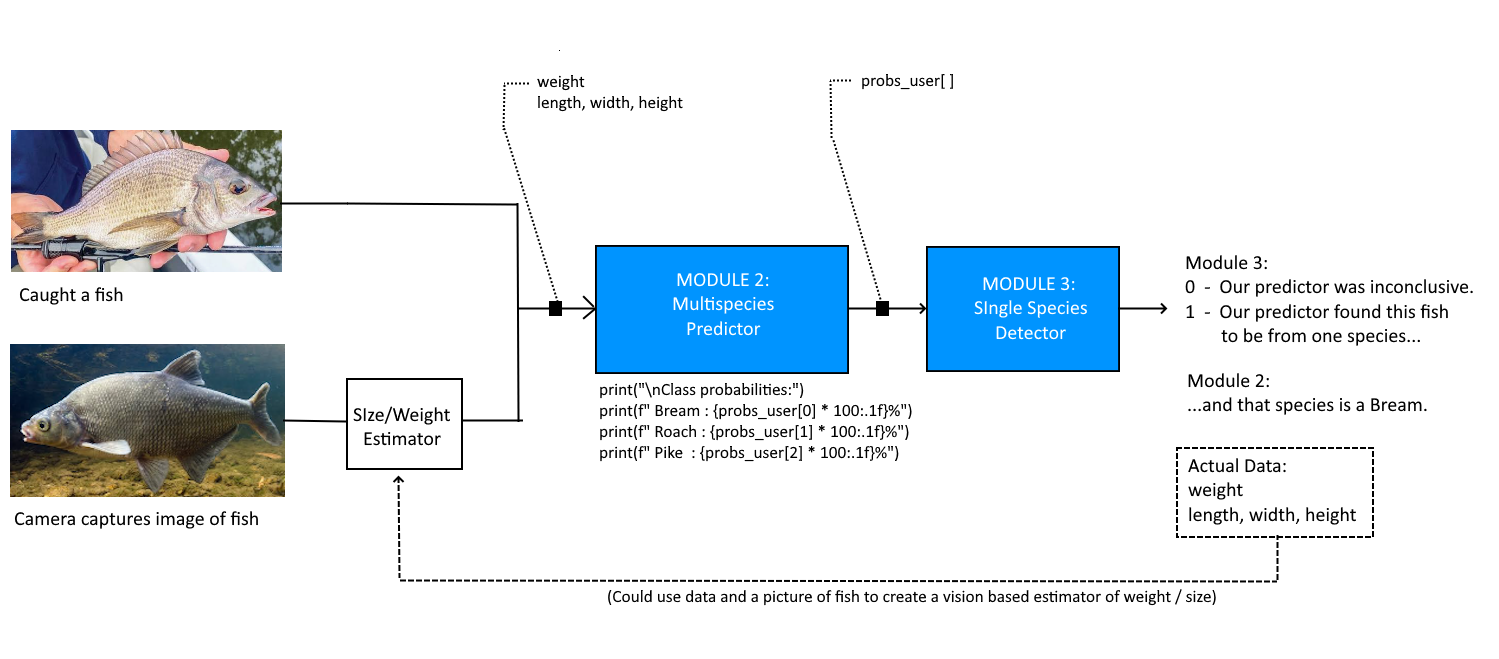

In electronics, this is a modified version of an Exclusive OR; or XOR. We are only looking for if the predictor said it was ONE species. Official equation is: X = (A ⊕ B ⊕ C) · ¬(A · B · C)
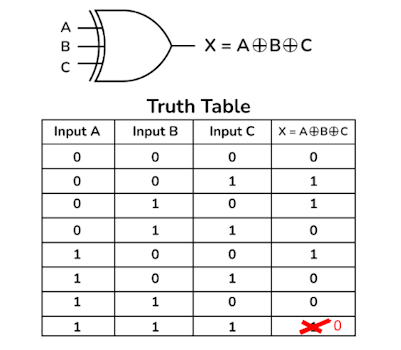

In this module, we will PURPOSELY not provide the entire logic even though we have it. We want to see if, with incomplete training data, we can apply a simple form of Machine Learning to infer this logic.  


# Section 1 : Setting up an incomplete Training set. 
Normally, a full 3 parameter exclusive OR matrix would have a full 8 combinations in it. 
But for our training matrix, we are purposely excluding [0, 1, 1] and [1, 1, 0]. Only 6 of the 8 will be used to train the NN. 

After getting through all the sections, come back here and experiment with taking away different rows than the 2 we selected. 

Ultimately -- what we hope to demonstrate is that with incomplete data, our techniques will create a model that has inferred what the real world should be when reinforced with validation with data from the outside world. 

In [1]:
# Imports

import numpy as np

# Each row is a training example, each column is a feature
# Training matrix is left incomplete on purpose.

X=np.array((
[0, 0, 0],
[0, 0, 1],
[0, 1, 0],
[1, 0, 0],
[1, 0, 1],
[1, 1, 1]), dtype=float)

# Output for the combinations. [0,1,1] and [1,1,0] would have both had 0's
y=np.array((
[0],
[1],
[1],
[1],
[0],
[0]), dtype=float)

# ============================================================

# Section 2 : Defining the Activation functions
We define the two useful activations and derivative functions.
This neural network does not rely on an AI framework. Sigmoids are easy enough to compute; and is the right one for making single-predictions.
See: https://builtin.com/machine-learning/sigmoid-activation-function

Since encountering the sigmoid in the 1990's, there are many other options. For hidden layers, the Rectified Linear Unit (ReLU) activation function is preferred over the sigmoid function in hidden layers and also works for inputs normalized from 0 - 1. 
General rule: 
  -  Sigmoid: Converts input into a probability-like value between 0 and 1, useful for binary classification.
  -  Tanh: Maps input to a range of –1 to +1, making it zero-centered and better for hidden layers
  -  ReLU: Outputs 0 for negative values and x for positive values, enabling faster and efficient training.


In [2]:
# ============================================================

# Define useful functions

# ============================================================

# Activation function

def sigmoid(t):
    return 1/(1+np.exp(-t))

# Derivative of sigmoid

def sigmoid_derivative(p):
    return p * (1 - p)

# Section 3 : Creating the Neural Network Class
This class implements a **feedforward neural network** with two hidden layers. 
Think of it as a series of connected "decision-makers" (neurons) that learn 
to solve a problem. 

The shape / size of the neural network is set by all the sections that start with self.<something>. 

In fact, the size of the hidden layers are defined here. 
        self.hiddenlayer_neurons = 4
        self.hiddenlayer2_neurons = 5
This is a small network. One that, after doing all the training, we could flatten and turn into just an equation that we run. 

**Key components:**

- **Initialization (`__init__`)**: Sets up the network architecture—defining how 
  many neurons in each layer, random starting weights, and the learning rate 
  (how aggressively the network learns).

- **Feedforward (`feedforward`)**: Sends input data through the network layer by 
  layer, applying weights and the sigmoid activation function to produce a prediction.

- **Backpropagation (`backprop`)**: The "learning" step. It calculates how wrong 
  the prediction was, traces that error backward through the network, and updates 
  the weights to do better next time.

- **Train (`train`)**: One training cycle—make a prediction, measure the error, 
  and learn from it.

- **Predict (`predict`)**: Use the trained network to make predictions on new data.

**The big picture**: The network starts with random guesses, but through many 
training cycles, the weights gradually improve until the network learns to 
make accurate predictions.

In [ ]:
# ============================================================

# Neural Network Class

# ============================================================

class NeuralNetwork:


    def __init__(self, x, y):
        
        # Initialize the Neural Network input to x
        self.input = x
        
        # Initialize the computed output set to be the same size as y
        self.y = y
        self.output = np.zeros(self.y.shape)
        
        # Define the size and hidden layers of the neural network
        self.lr = 0.9
        self.inputlayer_neurons = self.input.shape[1]
        self.hiddenlayer_neurons = 4
        self.hiddenlayer2_neurons = 5
        self.output_neurons = 1
        
        # Initialize the weights
        self.wh = np.random.uniform(
            size=(self.inputlayer_neurons, self.hiddenlayer_neurons)
        )
        
        self.wh2 = np.random.uniform(
            size=(self.hiddenlayer_neurons, self.hiddenlayer2_neurons)
        )
        
        self.wout = np.random.uniform(
            size=(self.hiddenlayer2_neurons, self.output_neurons)
        )
        
        # Initialize activation layer storage
        self.hiddenlayer_activations = np.random.uniform(
            size=(self.hiddenlayer_neurons, self.output.shape[1])
        )
        
        self.hiddenlayer2_activations = np.random.uniform(
            size=(self.hiddenlayer_neurons, self.hiddenlayer2_neurons)
        )
        
        
    # ========================================================
    # Feedforward
    # ========================================================
    
    def feedforward(self):
        
        hidden_layer_input = np.dot(self.input, self.wh)
        
        self.hiddenlayer_activations = sigmoid(hidden_layer_input)
        
        hiddenlayer2_input = np.dot(
            self.hiddenlayer_activations,
            self.wh2
        )
        
        self.hiddenlayer2_activations = sigmoid(hiddenlayer2_input)
        
        output_layer_input = np.dot(
            self.hiddenlayer2_activations,
            self.wout
        )
        
        return sigmoid(output_layer_input)
        
        
    # ========================================================
    # Backpropagation
    # ========================================================
    
    def backprop(self):
        
        # Calculate the slopes
        slope_output_layer = sigmoid_derivative(self.output)
        
        slope_hidden_layer2 = sigmoid_derivative(
            self.hiddenlayer2_activations
        )
        
        slope_hidden_layer = sigmoid_derivative(
            self.hiddenlayer_activations
        )
        
        # Calculate errors
        E = self.y - self.output
        
        d_output = E * slope_output_layer
        
        Error_at_hidden_layer2 = d_output.dot(self.wout.T)
        
        d_hiddenlayer2 = (
            Error_at_hidden_layer2 *
            slope_hidden_layer2
        )
        
        Error_at_hidden_layer = (
            Error_at_hidden_layer2.dot(self.wh2.T)
        )
        
        d_hiddenlayer = (
            Error_at_hidden_layer *
            slope_hidden_layer
        )
        
        # Update the weights
        self.wout += (
            self.hiddenlayer2_activations.T.dot(d_output)
            * self.lr
        )
        
        self.wh2 += (
            self.hiddenlayer_activations.T.dot(d_hiddenlayer2)
            * self.lr
        )
        
        self.wh += (
            self.input.T.dot(d_hiddenlayer)
            * self.lr
        )
        
        
    # ========================================================
    # Train
    # ========================================================
    
    def train(self, X, y):
        
        self.output = self.feedforward()
        self.backprop()
        
        
    # ========================================================
    # Predict
    # ========================================================
    
    def predict(self, X):
        
        self.input = X
        
        return self.feedforward()


# Section 4 : Creating and Training the Neural Network
This where we create the neural network.  Unlike module 2 and module 1, we can't assume the very last Epoch will have the very best results.
The following figure represent visually what could be happening Epoch to Epoch.  Source of the figure is from "A Stability Boundary Based Method for Finding Saddle Points on Potential Energy Surfaces" by Chandan K Reddy and Hsiao-Dong Chiang, 2006. Their article has nothing to do with ML; but the visualization is really nice.
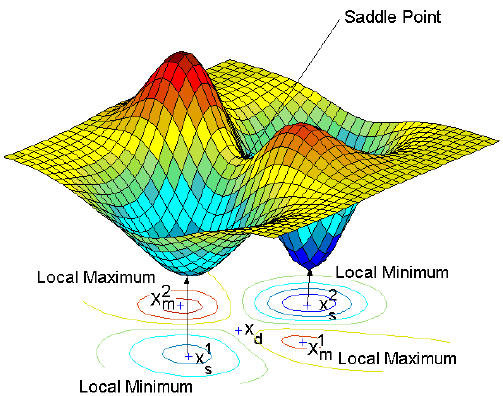

Though the backprogation is adjust weights to get to a smaller and smaller error. We have tuned the Learning Rate to be big enough to bump it out of what could be a local miniumum.  Hence the extra section on Machine Learning. As it goes through the training, we retain the set of waits that has the lowest mean square error. And at the end of 1000 runs; we hope to have weights that can both do well with original incomplete input data. 

In [ ]:
# ============================================================
# Create Neural Network
# ============================================================

NN = NeuralNetwork(X, y)

# ============================================================
# MACHINE LEARNING: BEST WEIGHT TRACKING
# We could have just relied on letting the NN run and see where
# it ends. But with incomplete data, small data sets, we can
# not assume the last Epoch will necessarily be the best Epoch.
# ============================================================
# Start with an infinitely high loss.
# The first calculated loss will automatically become
# the best loss.

best_loss = float("inf")

# These will store the weights associated with best_loss.

best_wh = None
best_wh2 = None
best_wout = None

# ============================================================
# Train the Neural Network
# ============================================================

for i in range(1000):

    # Train the network
    NN.train(X, y)
    
    # Calculate the current loss AFTER the weight update
    predictions = NN.feedforward()
    current_loss = np.mean(np.square(y - predictions))


# --------------------------------------------------------
# MACHINE LEARNING REWARD:
# The best weights are the ones with the smallest loss
# This code check whether this is the best model so far
# --------------------------------------------------------

if current_loss < best_loss:
    
    # Save the new best loss
    best_loss = current_loss
    
    # IMPORTANT:
    # Make copies of the weights.
    # We use .copy() so later training does not overwrite
    # our saved best weights.
    best_wh = NN.wh.copy()
    best_wh2 = NN.wh2.copy()
    best_wout = NN.wout.copy()


# --------------------------------------------------------
# Display progress every 500 iterations
# --------------------------------------------------------

if i % 50 == 0:
    
    print("for iteration # " + str(i) + "\n")
    print("Input : \n" + str(X))
    print("Actual Output: \n" + str(y))
    print("Predicted Output: \n" + str(predictions))
    print("Loss: \n" + str(current_loss))
    print("Best Loss So Far: \n" + str(best_loss))
    print("\n")


# Section 5 : Restoring Best Weights
We now restore the very best weights -- that hopefully will give us the Global minimums.
We put the Training set in one more time to show you all how well it performed.

In [ ]:
# ============================================================
# RESTORE THE BEST WEIGHTS
# ============================================================
# The network has now completed training.
# Replace the final weights with the weights that produced
# the LOWEST training loss.

NN.wh = best_wh.copy()
NN.wh2 = best_wh2.copy()
NN.wout = best_wout.copy()

# ============================================================

# Final Training Results Using BEST WEIGHTS

# ============================================================

final_training_predictions = NN.predict(X)

final_training_loss = np.mean(
np.square(y - final_training_predictions)
)

print("\n========================================")
print("BEST MODEL")
print("========================================")
print("Lowest Training Loss:")
print(final_training_loss)

print("\nPredictions Using Best Weights:")
print(final_training_predictions)


# Section 6 : Machine Learning Magic
Now. We've used incomplete training data. This is the reality of the world we live in.  
What we are looking for is if it can infer the behavior of that modified XOR we mentioned earlier. 
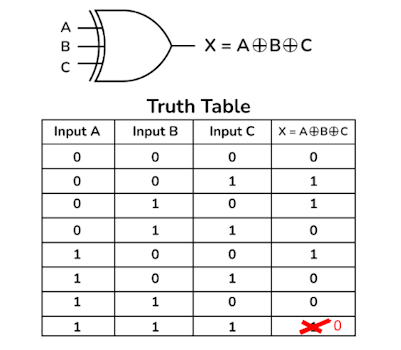

In this next section, we create all the possible combinations in X2. 
If the output, y2, matches the equation: X = (A ⊕ B ⊕ C) · ¬(A · B · C), then we've done it!!!!

Why does this module matter? 
1. As we get into Vision AI, the method of storing best weights is just assumed. 2D images have enough complexity to them that we know we need to avoid local-minimums.
2. With AI, models come and go. LLMs, Diffusion Models of today will most get a different approach tomorrow. One of the tests of a good AI system is to see if it can handle the Modified XOR logic X = (A ⊕ B ⊕ C) · ¬(A · B · C) 

In [ ]:
# ============================================================
# Final Prediction / Test Data
# ============================================================

X2 = np.array((
[0,0,0],
[0,0,1],
[0,1,0],
[0,1,1],
[1,0,0],
[1,0,1],
[1,1,0],
[1,1,1]
), dtype=float)

y2 = np.array((
[0],
[1],
[1],
[0],
[1],
[0],
[0],
[0]
), dtype=float)

# Predict using the BEST weights
predictions = NN.predict(X2)

# Calculate test loss
test_loss = np.mean(
np.square(y2 - predictions)
)

# ============================================================
# Display Final Prediction
# ============================================================
print("\n========================================")
print("FINAL TEST USING BEST MODEL")
print("========================================")
print("Input : \n", X2)
print("Expected Output: \n", y2)
print("Predicted Output: \n", predictions)
print("Test Loss: \n", test_loss)
print("\nLowest Training Loss: ", best_loss)

# Appendix 

This is the entire source code


For those that want to run this as one whole program. 

In [ ]:
# Imports

import numpy as np

# Each row is a training example, each column is a feature

X=np.array((
[0, 0, 0],
[0, 0, 1],
[0, 1, 0],
[1, 0, 0],
[1, 0, 1],
[1, 1, 1]), dtype=float)

y=np.array((
[0],
[1],
[1],
[1],
[0],
[0]), dtype=float)

# ============================================================

# Define useful functions

# ============================================================

# Activation function

def sigmoid(t):
    return 1/(1+np.exp(-t))

# Derivative of sigmoid

def sigmoid_derivative(p):
    return p * (1 - p)

# ============================================================

# Neural Network Class

# ============================================================

class NeuralNetwork:


    def __init__(self, x, y):
        
        # Initialize the Neural Network input to x
        self.input = x
        
        # Initialize the computed output set to be the same size as y
        self.y = y
        self.output = np.zeros(self.y.shape)
        
        # Define the size and hidden layers of the neural network
        self.lr = 0.9
        self.inputlayer_neurons = self.input.shape[1]
        self.hiddenlayer_neurons = 4
        self.hiddenlayer2_neurons = 5
        self.output_neurons = 1
        
        # Initialize the weights
        self.wh = np.random.uniform(
            size=(self.inputlayer_neurons, self.hiddenlayer_neurons)
        )
        
        self.wh2 = np.random.uniform(
            size=(self.hiddenlayer_neurons, self.hiddenlayer2_neurons)
        )
        
        self.wout = np.random.uniform(
            size=(self.hiddenlayer2_neurons, self.output_neurons)
        )
        
        # Initialize activation layer storage
        self.hiddenlayer_activations = np.random.uniform(
            size=(self.hiddenlayer_neurons, self.output.shape[1])
        )
        
        self.hiddenlayer2_activations = np.random.uniform(
            size=(self.hiddenlayer_neurons, self.hiddenlayer2_neurons)
        )
        
        
    # ========================================================
    # Feedforward
    # ========================================================
    
    def feedforward(self):
        
        hidden_layer_input = np.dot(self.input, self.wh)
        
        self.hiddenlayer_activations = sigmoid(hidden_layer_input)
        
        hiddenlayer2_input = np.dot(
            self.hiddenlayer_activations,
            self.wh2
        )
        
        self.hiddenlayer2_activations = sigmoid(hiddenlayer2_input)
        
        output_layer_input = np.dot(
            self.hiddenlayer2_activations,
            self.wout
        )
        
        return sigmoid(output_layer_input)
        
        
    # ========================================================
    # Backpropagation
    # ========================================================
    
    def backprop(self):
        
        # Calculate the slopes
        slope_output_layer = sigmoid_derivative(self.output)
        
        slope_hidden_layer2 = sigmoid_derivative(
            self.hiddenlayer2_activations
        )
        
        slope_hidden_layer = sigmoid_derivative(
            self.hiddenlayer_activations
        )
        
        # Calculate errors
        E = self.y - self.output
        
        d_output = E * slope_output_layer
        
        Error_at_hidden_layer2 = d_output.dot(self.wout.T)
        
        d_hiddenlayer2 = (
            Error_at_hidden_layer2 *
            slope_hidden_layer2
        )
        
        Error_at_hidden_layer = (
            Error_at_hidden_layer2.dot(self.wh2.T)
        )
        
        d_hiddenlayer = (
            Error_at_hidden_layer *
            slope_hidden_layer
        )
        
        # Update the weights
        self.wout += (
            self.hiddenlayer2_activations.T.dot(d_output)
            * self.lr
        )
        
        self.wh2 += (
            self.hiddenlayer_activations.T.dot(d_hiddenlayer2)
            * self.lr
        )
        
        self.wh += (
            self.input.T.dot(d_hiddenlayer)
            * self.lr
        )
        
        
    # ========================================================
    # Train
    # ========================================================
    
    def train(self, X, y):
        
        self.output = self.feedforward()
        self.backprop()
        
        
    # ========================================================
    # Predict
    # ========================================================
    
    def predict(self, X):
        
        self.input = X
        
        return self.feedforward()

# ============================================================
# Create Neural Network
# ============================================================

NN = NeuralNetwork(X, y)

# ============================================================
# MACHINE LEARNING: BEST WEIGHT TRACKING
# We could have just relied on letting the NN run and see where
# it ends. But with incomplete data, small data sets, we can
# not assume the last Epoch will necessarily be the best Epoch.
# ============================================================
# Start with an infinitely high loss.
# The first calculated loss will automatically become
# the best loss.

best_loss = float("inf")

# These will store the weights associated with best_loss.

best_wh = None
best_wh2 = None
best_wout = None

# ============================================================
# Train the Neural Network
# ============================================================

for i in range(1000):

    # Train the network
    NN.train(X, y)
    
    # Calculate the current loss AFTER the weight update
    predictions = NN.feedforward()
    current_loss = np.mean(np.square(y - predictions))


# --------------------------------------------------------
# MACHINE LEARNING REWARD:
# The best weights are the ones with the smallest loss
# This code check whether this is the best model so far
# --------------------------------------------------------

if current_loss < best_loss:
    
    # Save the new best loss
    best_loss = current_loss
    
    # IMPORTANT:
    # Make copies of the weights.
    # We use .copy() so later training does not overwrite
    # our saved best weights.
    best_wh = NN.wh.copy()
    best_wh2 = NN.wh2.copy()
    best_wout = NN.wout.copy()


# --------------------------------------------------------
# Display progress every 500 iterations
# --------------------------------------------------------

if i % 50 == 0:
    
    print("for iteration # " + str(i) + "\n")
    print("Input : \n" + str(X))
    print("Actual Output: \n" + str(y))
    print("Predicted Output: \n" + str(predictions))
    print("Loss: \n" + str(current_loss))
    print("Best Loss So Far: \n" + str(best_loss))
    print("\n")

# ============================================================
# RESTORE THE BEST WEIGHTS
# ============================================================
# The network has now completed training.
# Replace the final weights with the weights that produced
# the LOWEST training loss.

NN.wh = best_wh.copy()
NN.wh2 = best_wh2.copy()
NN.wout = best_wout.copy()

# ============================================================

# Final Training Results Using BEST WEIGHTS

# ============================================================

final_training_predictions = NN.predict(X)

final_training_loss = np.mean(
np.square(y - final_training_predictions)
)

print("\n========================================")
print("BEST MODEL")
print("========================================")
print("Lowest Training Loss:")
print(final_training_loss)

print("\nPredictions Using Best Weights:")
print(final_training_predictions)

# ============================================================
# Final Prediction / Test Data
# ============================================================

X2 = np.array((
[0,0,0],
[0,0,1],
[0,1,0],
[0,1,1],
[1,0,0],
[1,0,1],
[1,1,0],
[1,1,1]
), dtype=float)

y2 = np.array((
[0],
[1],
[1],
[0],
[1],
[0],
[0],
[0]
), dtype=float)

# Predict using the BEST weights
predictions = NN.predict(X2)

# Calculate test loss
test_loss = np.mean(
np.square(y2 - predictions)
)

# ============================================================
# Display Final Prediction
# ============================================================
print("\n========================================")
print("FINAL TEST USING BEST MODEL")
print("========================================")
print("Input : \n", X2)
print("Expected Output: \n", y2)
print("Predicted Output: \n", predictions)
print("Test Loss: \n", test_loss)
print("\nLowest Training Loss: ", best_loss)